## Dataset Overview

We use daily mean OLR (`olr`) from 1979–2000 between 30°S–30°N. The dataset includes dimensions `time`, `lat`, and `lon` and is suitable for demonstrating temporal filtering and spectral analysis.

# Geophysical Signal Tools Tutorial

This tutorial shows how to use the `spectral_analysis` module (`spa`) to:
- Load OLR data with `xarray`
- Compute power spectra
- Apply 1D and 3D filters (lowpass, highpass, bandpass)
- Remove seasonal cycles using harmonic regression

We'll work with the sample dataset `olr.day.mean_1979_2000_30S30N.nc` shipped in this folder.

In [ ]:
def compute_power_spectrum(time_series):
    """
    Computes the normalized power spectrum (percentage of variance) of a
    time series using the Fourier transform.

    Args:
        time_series (array-like): The input time series data.

    Returns:
        tuple: (periods, percent_variance) where
            periods (np.ndarray): Array of periods corresponding to the Fourier
                frequencies.
            percent_variance (np.ndarray): Percentage of variance explained by
                each frequency component.
    """
    import numpy as np
    sampling_interval = 1
    mean_value = np.mean(time_series)
    detrended_series = time_series - mean_value

    freqs = np.fft.fftfreq(len(detrended_series), sampling_interval)
    periods = 1 / freqs

    fourier_transform = np.fft.fft(detrended_series)
    amplitude = np.abs(fourier_transform)
    power = amplitude ** 2
    normalized_power = (power / np.sum(power)) * np.var(detrended_series)
    percent_variance = (normalized_power / np.var(detrended_series)) * 100.0

    return periods, percent_variance

def plot_power_spectrum(serie):
    """
    Plots the Fourier spectra of a time series.

    Args:
      serie (array-like): Input time series data.

    Returns:
      matplotlib.figure.Figure: The figure object containing the plot.
    """
    import matplotlib.pyplot as plt

    # Compute spectrum using the dedicated function
    periods, percent_variance = compute_power_spectrum(serie)

    # Plot the magnitude of the FFT
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(periods, percent_variance * 2, color='k')
    ax.set_xscale('log', base=10)
    ax.set_xlabel('Period')
    ax.set_ylabel('Explained variance [%]')
    ax.set_title('Fourier Spectra')
    ax.grid(True)

    return fig, ax

In [1]:

import spectral_analysis as spa

import numpy as np
import xarray as xr


olr_xr = xr.open_dataset('olr.day.mean_1979_2000_30S30N.nc')

<xarray.Dataset> Size: 116MB
Dimensions:  (time: 8036, nmiss: 7, lat: 25, lon: 144)
Coordinates:
  * time     (time) datetime64[ns] 64kB 1979-01-01 1979-01-02 ... 2000-12-31
  * lon      (lon) float32 576B -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
  * lat      (lat) float32 100B 30.0 27.5 25.0 22.5 ... -22.5 -25.0 -27.5 -30.0
Dimensions without coordinates: nmiss
Data variables:
    info     (time, nmiss) float32 225kB ...
    olr      (time, lat, lon) float32 116MB 263.4 264.5 252.5 ... 242.5 228.0
Attributes:
    CDI:            Climate Data Interface version 2.5.4 (https://mpimet.mpg....
    Conventions:    CF-1.2
    source:         ftp.cpc.ncep.noaa.gov precip/noaa..
    title:          Daily Mean Interpolated OLR
    description:    Data is interpolated in time and space from NOAA twice-da...
    platform:       Observation
    References:     https://www.psl.noaa.gov/data/gridded/data.interp_OLR.html
    NCO:            4.0.0
    Citation:       Liebmann and Smith: June 2006: D

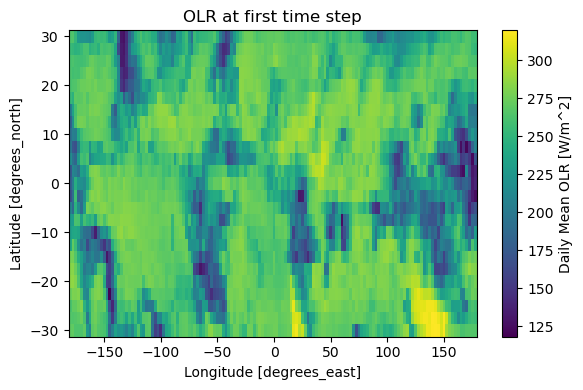

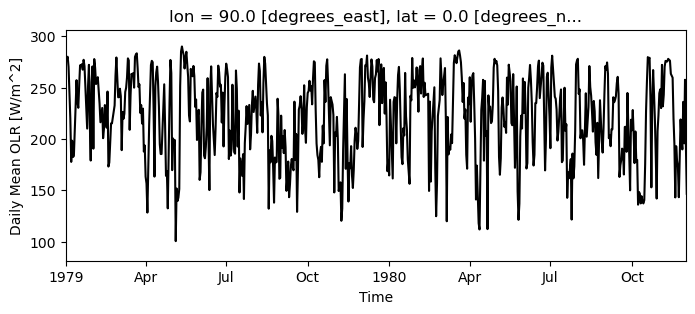

In [27]:
# Inspect dataset and preview
import matplotlib.pyplot as plt

# The dataset was opened above as `olr_xr`
print(olr_xr)
da = olr_xr['olr']
print('dims:', da.dims)
print('shape:', da.shape)

# Plot a map at the first time step
plt.figure(figsize=(6,4))
da.isel(time=0).plot()
plt.title('OLR at first time step')
plt.tight_layout()
plt.show()

lon, lat = 90, 0

# Compute and plot the spatial mean time series
olr_series = olr_xr.sel(lon=lon, lat=lat, method='nearest')['olr']
plt.figure(figsize=(8, 3))
plt.xlim(olr_series['time'].values[0], olr_series['time'].values[700])
olr_series.plot(color='k')


## Power Spectrum

We compute the normalized power spectrum (percentage of variance) of a time series using `spa.compute_power_spectrum()` and plot with `spa.plot_power_spectrum()`.

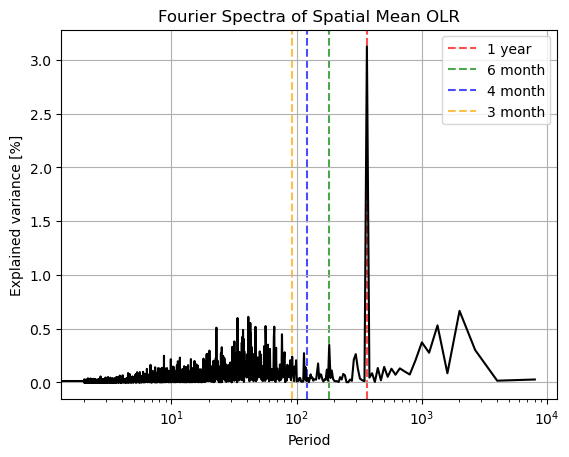

In [ ]:
# Compute and plot power spectrum of spatial mean
periods, pct_var = compute_power_spectrum(olr_series.values)

fig, ax = plot_power_spectrum(olr_series.values)
ax.set_title('Fourier Spectra of Spatial Mean OLR')

# Mark harmonics of the annual cycle
harmonics = {
    365.25: ('1 year', 'red'),
    182.625: ('6 month', 'green'),
    121.75: ('4 month', 'blue'),
    91.3125: ('3 month', 'orange'),
}

for period, (label, color) in harmonics.items():
    ax.axvline(period, color=color, linestyle='--', 
               label=label, zorder=0, alpha=0.7)
ax.legend()


## 1D Filters

We apply filters to a single time series. Here, we use the spatial mean time series for simplicity:
- Lowpass: keeps periods longer than the cutoff
- Highpass: keeps periods shorter than the cutoff
- Bandpass: keeps periods within a period range

In [ ]:
def bandpass_filter(series, low_period, high_period):
    '''
    Apply a bandpass filter to a time series using the Fourier transform.
    Keeps frequencies corresponding to periods between low_period and high_period.

    Parameters:
        series (array-like): Input time series data.
        low_period (float): Lower bound of the period (shorter period, higher frequency).
        high_period (float): Upper bound of the period (longer period, lower frequency).

    Returns:
        np.ndarray: Filtered time series.
    '''
    import numpy as np
    sampling_interval = 1
    mean_value = np.mean(series)
    detrended_series = series - mean_value

    freqs = np.fft.fftfreq(len(detrended_series), sampling_interval)
    # Handle division by zero
    periods = np.where(freqs != 0, 1 / np.abs(freqs), np.inf)

    # Keep frequencies with periods in [low_period, high_period]
    filter_mask = (periods >= low_period) & (periods <= high_period)

    fourier_coeffs = np.fft.fft(detrended_series)
    fourier_coeffs[~filter_mask] = 0

    filtered_series = np.fft.ifft(fourier_coeffs).real
    filtered_series += mean_value

    return filtered_series


def lowpass_filter(series, cutoff_period):
    '''
    Apply a lowpass filter to a time series using the Fourier transform.
    It passes signals with a frequency lower than a selected cutoff frequency
    and attenuates signals with frequencies higher than the cutoff frequency.

    Parameters:
        series (array-like): Input time series data.
        cutoff_period (float): Cutoff period for the lowpass filter.

    Returns:
        np.ndarray: Filtered time series.
    '''
    import numpy as np
    sampling_interval = 1
    mean_value = np.mean(series)
    detrended_series = series - mean_value

    freqs = np.fft.fftfreq(len(detrended_series), sampling_interval)
    # Handle division by zero
    periods = 1 / np.where(freqs != 0, freqs, np.inf)

    # Mask frequencies with periods SHORTER than cutoff (higher frequencies)
    filter_mask = np.abs(periods) < cutoff_period

    fourier_coeffs = np.fft.fft(detrended_series)
    fourier_coeffs[filter_mask] = 0  # Remove high frequencies

    filtered_series = np.fft.ifft(fourier_coeffs).real
    filtered_series += mean_value

    return filtered_series


def highpass_filter(series, cutoff_period):
    '''
    Apply a highpass filter to a time series using the Fourier transform.

    Parameters:
        series (array-like): Input time series data.
        cutoff_period (float): Cutoff period for the highpass filter.

    Returns:
        np.ndarray: Filtered time series.
    '''
    import numpy as np
    sampling_interval = 1
    mean_value = np.mean(series)
    detrended_series = series - mean_value

    freqs = np.fft.fftfreq(len(detrended_series), sampling_interval)
    periods = 1 / np.where(freqs != 0, freqs, np.inf)

    # Mask frequencies below the cutoff period
    filter_mask = np.abs(periods) > cutoff_period

    fourier_coeffs = np.fft.fft(detrended_series)
    fourier_coeffs[filter_mask] = 0

    filtered_series = np.fft.ifft(fourier_coeffs).real
    filtered_series += mean_value

    return filtered_series

Text(0.5, 1.0, 'Bandpass Filtered Spectrum [20-90 days]')

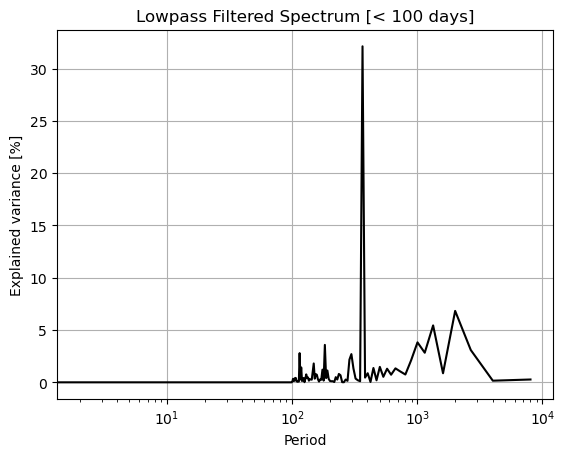

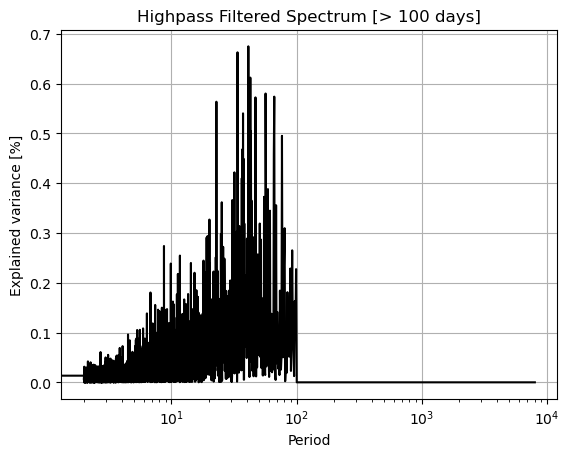

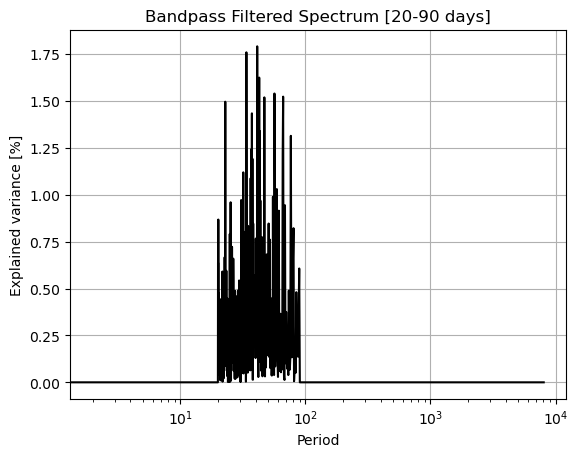

In [ ]:
# Apply 1D filters to spatial mean
cutoff_days = 100
bp_low, bp_high = 20, 90

olr_low = lowpass_filter(olr_series.values, cutoff_days)
olr_high = highpass_filter(olr_series.values, cutoff_days)
olr_band = bandpass_filter(olr_series.values, bp_low, bp_high)

fig, ax = plot_power_spectrum(olr_low)
ax.set_title(f'Lowpass Filtered Spectrum [< {cutoff_days} days]')
fig, ax = plot_power_spectrum(olr_high)
ax.set_title(f'Highpass Filtered Spectrum [> {cutoff_days} days]')
fig, ax = plot_power_spectrum(olr_band)
ax.set_title(f'Bandpass Filtered Spectrum [{bp_low}-{bp_high} days]')

